      #YY  MM  DD  hh  mm  WDIR  WSPD   GST  WVHT   DPD   APD  MWD    PRES  \
205  2022   9  13   0   0   999  99.0  99.0  0.47  6.90  3.25  109  9999.0   
206  2022   9  13   0  30   999  99.0  99.0  0.48  6.90  3.16  101  9999.0   
207  2022   9  13   1   0   999  99.0  99.0  0.51  6.90  3.40  106  9999.0   
208  2022   9  13   1  30   999  99.0  99.0  0.49  6.25  3.29  115  9999.0   
209  2022   9  13   2   0   999  99.0  99.0  0.51  6.90  3.23  107  9999.0   
..    ...  ..  ..  ..  ..   ...   ...   ...   ...   ...   ...  ...     ...   
729  2022   9  23  22   0   999  99.0  99.0  0.60  5.13  2.92  109  9999.0   
730  2022   9  23  22  30   999  99.0  99.0  0.59  2.99  2.82  130  9999.0   
731  2022   9  23  23   0   999  99.0  99.0  0.63  3.39  2.98  107  9999.0   
732  2022   9  23  23  30   999  99.0  99.0  0.60  3.39  2.91  113  9999.0   
733  2022   9  24   0   0   999  99.0  99.0  0.64  3.45  2.91   99  9999.0   

      ATMP  WTMP   DEWP   VIS  TIDE            datetime  
205  

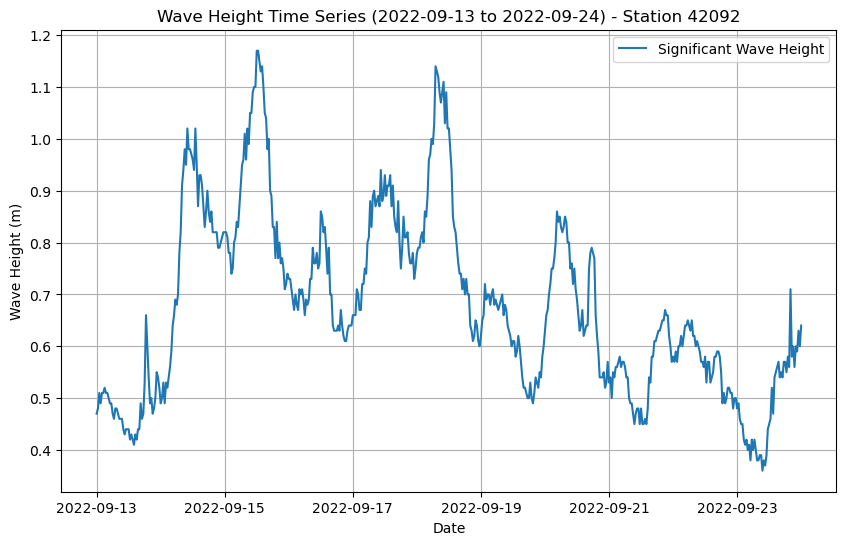

In [14]:
import pandas as pd
import requests
from io import StringIO
import matplotlib.pyplot as plt

def fetch_noaa_data(station_id, year, start_date, end_date):
    """
    Fetch historical wave data for a given station and time period.
    
    Parameters:
    station_id (str): The WMO Station Identifier.
    year (str): The year for which to fetch data.
    start_date (str): The start date in the format YYYY-MM-DD.
    end_date (str): The end date in the format YYYY-MM-DD.

    Returns:
    pd.DataFrame: The wave data for the specified period.
    """
    url = f"https://www.ndbc.noaa.gov/view_text_file.php?filename={station_id}h{year}.txt.gz&dir=data/historical/stdmet/"
    response = requests.get(url)
    
    if response.status_code == 200:
        data = StringIO(response.content.decode('utf-8'))
        df = pd.read_csv(data, delim_whitespace=True, skiprows=[1])  # Skip the second row header
        
        # Convert date and time to datetime format
        df['datetime'] = pd.to_datetime(df[['#YY', 'MM', 'DD', 'hh', 'mm']].rename(
            columns={'#YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'minute'}))
        
        # Filter the data by date range
        mask = (df['datetime'] >= start_date) & (df['datetime'] <= end_date)
        df_filtered = df.loc[mask]
        
        return df_filtered
    else:
        raise Exception(f"Error fetching data: {response.status_code}")

# Example usage
station_id = "42092"
year = "2022"
start_date = "2022-09-13"
end_date = "2022-09-24"

wave_data = fetch_noaa_data(station_id, year, start_date, end_date)

# Display the filtered data
print(wave_data)
wave_height_timeseries = wave_data[['datetime', 'WVHT']]
excel_file = f"wave_height_timeseries_{station_id}_{start_date}_to_{end_date}.xlsx"
wave_height_timeseries.to_excel(excel_file, index=False)
print(f"Data saved to {excel_file}")

# Plotting the time series
plt.figure(figsize=(10, 6))
plt.plot(wave_data['datetime'], wave_data['WVHT'], label='Significant Wave Height')
plt.xlabel('Date')
plt.ylabel('Wave Height (m)')
plt.title(f'Wave Height Time Series ({start_date} to {end_date}) - Station {station_id}')
plt.legend()
plt.grid(True)
plt.show()


In [3]:
import pandas as pd
import requests
from io import StringIO
import matplotlib.pyplot as plt

def fetch_noaa_data(station_id, year, start_date, end_date):
    """
    Fetch historical wave data for a given station and time period.
    
    Parameters:
    station_id (str): The WMO Station Identifier.
    year (str): The year for which to fetch data.
    start_date (str): The start date in the format YYYY-MM-DD.
    end_date (str): The end date in the format YYYY-MM-DD.

    Returns:
    pd.DataFrame: The wave data for the specified period.
    """
    url = f"https://www.ndbc.noaa.gov/view_text_file.php?filename={station_id}h{year}.txt.gz&dir=data/historical/stdmet/"
    response = requests.get(url)
    
    if response.status_code == 200:
        data = StringIO(response.content.decode('utf-8'))
        df = pd.read_csv(data, delim_whitespace=True, skiprows=[1])  # Skip the second row header
        
        # Convert date and time to datetime format
        df['datetime'] = pd.to_datetime(df[['#YY', 'MM', 'DD', 'hh', 'mm']].rename(
            columns={'#YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'minute'}))
        
        # Filter the data by date range
        mask = (df['datetime'] >= start_date) & (df['datetime'] <= end_date)
        df_filtered = df.loc[mask]
        
        return df_filtered
    else:
        raise Exception(f"Error fetching data: {response.status_code}")

# Example usage
station_id = "42092"
year = "2017"
start_date = "2017-08-20"
end_date = "2017-08-30"

wave_data = fetch_noaa_data(station_id, year, start_date, end_date)

# Display the filtered data
print(wave_data)
wave_height_timeseries = wave_data[['datetime', 'WVHT']]
excel_file = f"wave_height_timeseries_{station_id}_{start_date}_to_{end_date}.xlsx"
wave_height_timeseries.to_excel(excel_file, index=False)
print(f"Data saved to {excel_file}")

# Plotting the time series
plt.figure(figsize=(10, 6))
plt.plot(wave_data['datetime'], wave_data['WVHT'], label='Significant Wave Height')
plt.xlabel('Date')
plt.ylabel('Wave Height (m)')
plt.title(f'Wave Height Time Series ({start_date} to {end_date}) - Station {station_id}')
plt.legend()
plt.grid(True)
plt.show()


Exception: Error fetching data: 404